In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from keras import optimizers
from keras.callbacks import History

# Dataset

In [2]:
car_evaluation = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data",
                            names=["buying", "maint", "doors", "persons", "lug_boot", "safety", "evaluation"])

car_evaluation.head()

,buying,maint,doors,persons,lug_boot,safety,evaluation
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
car_evaluation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   buying      1728 non-null   object
 1   maint       1728 non-null   object
 2   doors       1728 non-null   object
 3   persons     1728 non-null   object
 4   lug_boot    1728 non-null   object
 5   safety      1728 non-null   object
 6   evaluation  1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [4]:
car_evaluation["evaluation"].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

# Econding featuers e label

Per l'encoding delle features, mappo ogni valore testuale ad un valore numerico, per l'encoding delle label applico la one-hot encoding, codificando prima i valori testuali delle label in numeri tramite la classe LabelEncoder

In [5]:
buying_mapping = {"low":0, "med":1, "high":2, "vhigh":3}
car_evaluation["buying"] = car_evaluation["buying"].map(buying_mapping)

In [6]:
maint_mapping = {"low":0, "med":1, "high":2, "vhigh":3 }
car_evaluation["maint"] = car_evaluation["maint"].map(maint_mapping)

In [7]:
doors_mapping = {"2":2, "3":3, "4":4, "5more":5}
car_evaluation["doors"] = car_evaluation["doors"].map(doors_mapping)

In [8]:
persons_mapping = {"2":2, "4":4, "more":5}
car_evaluation["persons"] = car_evaluation["persons"].map(persons_mapping)

In [9]:
lug_boot_mapping = {"small":1, "med":2, "big":3}
car_evaluation["lug_boot"] = car_evaluation["lug_boot"].map(lug_boot_mapping)

In [10]:
safety_mapping = {"low":1, "med":2, "high":3}
car_evaluation["safety"] = car_evaluation["safety"].map(safety_mapping)

In [11]:
X = car_evaluation.drop('evaluation',axis=1).values
y = car_evaluation['evaluation'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

In [13]:
labels = ["unacc", "acc", "good", "vgood" ]

le = LabelEncoder()
#converto le label in valori numerici
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

#applico la one-hot encoding
y_train_dummy = to_categorical(y_train, 4)
y_test_dummy = to_categorical(y_test, 4)

In [14]:
y_test_dummy

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [15]:
y_train_dummy

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)

# Standardizzazione dei dati

In [16]:
#Applico la standardizzazione sui dati per portarli in valori di range comuni
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

# Creazione della rete neurale

In [17]:
from keras.models import Sequential
from keras.layers import Dense

In [18]:
model = Sequential()

In [19]:
model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                448       
_________________________________________________________________
dense_1 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_3 (Dense)              (None, 4)                 68        
Total params: 3,124
Trainable params: 3,124
Non-trainable params: 0
_________________________________________________________________


In [20]:
#come metodo di ottimizzazione utilizzo il nesterov momentum, con un valore di beta 0.9
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [21]:
history = History()

#train del modello
model.fit(X_train, y_train_dummy, epochs=100, batch_size=128, callbacks=[history])

Epoch 1/100
10/10 [==============================] - 0s 556us/step - loss: 1.2265 - accuracy: 0.5848
Epoch 2/100
10/10 [==============================] - 0s 556us/step - loss: 0.8867 - accuracy: 0.7039
Epoch 3/100
10/10 [==============================] - 0s 556us/step - loss: 0.7230 - accuracy: 0.7039
Epoch 4/100
10/10 [==============================] - 0s 556us/step - loss: 0.6140 - accuracy: 0.7047
Epoch 5/100
10/10 [==============================] - 0s 556us/step - loss: 0.5323 - accuracy: 0.7709
Epoch 6/100
10/10 [==============================] - 0s 445us/step - loss: 0.4739 - accuracy: 0.8073
Epoch 7/100
10/10 [==============================] - 0s 556us/step - loss: 0.4356 - accuracy: 0.8246
Epoch 8/100
10/10 [==============================] - 0s 667us/step - loss: 0.4087 - accuracy: 0.8445
Epoch 9/100
10/10 [==============================] - 0s 556us/step - loss: 0.3871 - accuracy: 0.8519
Epoch 10/100
10/10 [==============================] - 0s 556us/step - loss: 0.3691 - accura

10/10 [==============================] - 0s 445us/step - loss: 0.0359 - accuracy: 0.9926
Epoch 82/100
10/10 [==============================] - 0s 556us/step - loss: 0.0356 - accuracy: 0.9926
Epoch 83/100
10/10 [==============================] - 0s 556us/step - loss: 0.0354 - accuracy: 0.9909
Epoch 84/100
10/10 [==============================] - 0s 556us/step - loss: 0.0342 - accuracy: 0.9909
Epoch 85/100
10/10 [==============================] - 0s 444us/step - loss: 0.0339 - accuracy: 0.9934
Epoch 86/100
10/10 [==============================] - 0s 556us/step - loss: 0.0325 - accuracy: 0.9934
Epoch 87/100
10/10 [==============================] - 0s 556us/step - loss: 0.0320 - accuracy: 0.9934
Epoch 88/100
10/10 [==============================] - 0s 556us/step - loss: 0.0312 - accuracy: 0.9934
Epoch 89/100
10/10 [==============================] - 0s 556us/step - loss: 0.0312 - accuracy: 0.9934
Epoch 90/100
10/10 [==============================] - 0s 444us/step - loss: 0.0305 - accuracy: 

In [22]:
#valutazione del modello sul test set
model.evaluate(X_test, y_test_dummy)

17/17 [==============================] - 0s 438us/step - loss: 0.0657 - accuracy: 0.9769


[0.0657092034816742, 0.9768785834312439]

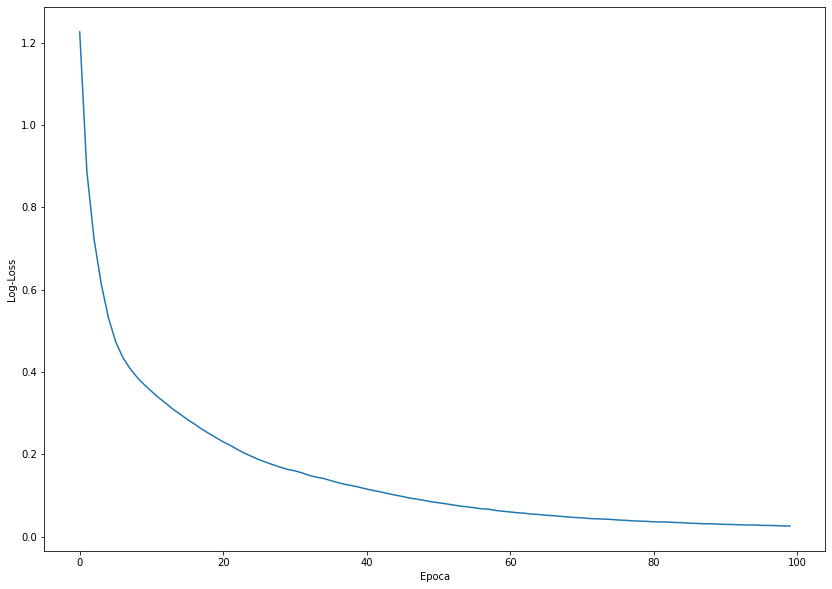

In [23]:
plt.figure(figsize=(14,10))
plt.xlabel("Epoca")
plt.ylabel("Log-Loss")
plt.plot(history.history['loss'])